# 06 · Evaluation and diagnostics
Validation is used for model selection and calibration; the test set was evaluated once (see `outputs/reports/test_access_log.jsonl`).

In [1]:
import os, pathlib
os.chdir(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd())
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from retail_targeting.config import load_config
cfg = load_config()
T = lambda name: pd.read_csv(f"outputs/tables/{name}")

In [2]:
T('model_metrics.csv')[['model','split','prevalence','pr_auc','roc_auc','brier','precision_at_0.1','lift_at_0.1']]

,model,split,prevalence,pr_auc,roc_auc,brier,precision_at_0.1,lift_at_0.1
0,rfm_benchmark,validation,0.457611,0.718095,0.743903,NaN,0.876972,1.916412
1,logreg_raw,validation,0.457611,0.745407,0.745039,0.204535,0.922713,2.016369
2,logreg_calibrated,validation (in-sample for calibration),0.457611,0.745407,0.745039,0.199004,0.922713,2.016369
3,logreg_raw_no_seasonality (D22 ablation),validation,0.457611,0.742985,0.743464,0.201306,0.927445,2.026710
4,logreg_raw,train,0.497519,0.770429,0.757631,0.198842,0.921601,1.852392


In [3]:
T('model_metrics_test.csv')[['model','prevalence','pr_auc','roc_auc','brier','mean_predicted','precision_at_0.1','lift_at_0.1']]

,model,prevalence,pr_auc,roc_auc,brier,mean_predicted,precision_at_0.1,lift_at_0.1
0,rfm_benchmark,0.581858,0.785671,0.724840,NaN,NaN,0.902351,1.550810
1,logreg_raw,0.581858,0.816190,0.744122,0.201328,0.616546,0.951175,1.634722
2,logreg_calibrated,0.581858,0.816190,0.744122,0.215610,0.699310,0.951175,1.634722


In [4]:
T('calibration_in_the_large_test.csv')

,decision_date,n,prevalence,mean_p_calibrated,mean_p_raw,calibration_in_the_large
0,2011-08-01,2766,0.556761,0.699000,0.615979,-0.142239
1,2011-09-01,2768,0.606936,0.699619,0.617113,-0.092683


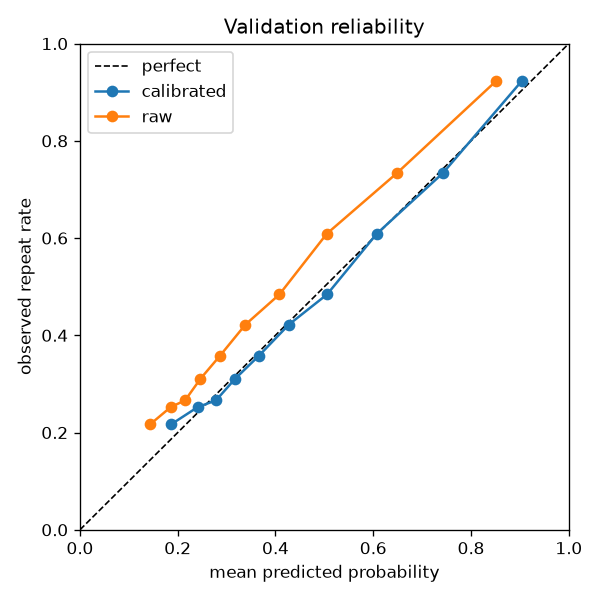

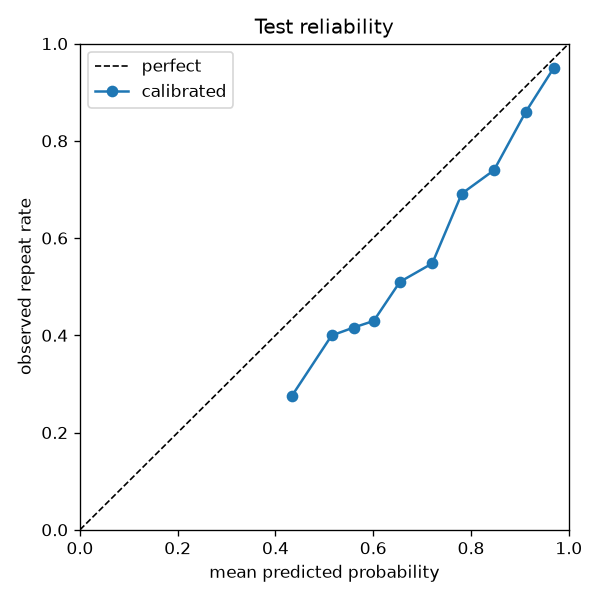

In [5]:
display(Image('outputs/figures/reliability_validation.png')); display(Image('outputs/figures/reliability_test.png'))

In [6]:
T('metrics_by_group_test.csv')[['group','group_value','n','prevalence','pr_auc','roc_auc']]

,group,group_value,n,prevalence,pr_auc,roc_auc
0,customer_segment,Developing,1258,0.662957,0.800673,0.671788
1,customer_segment,Dormant,2033,0.403345,0.525536,0.633682
2,customer_segment,High-value active,1204,0.843854,0.947236,0.773659
3,customer_segment,High-value at risk,464,0.659483,0.763715,0.670597
4,customer_segment,Low-value active,575,0.424348,0.426671,0.497895
5,decision_date,2011-08-01 00:00:00,2766,0.556761,0.806763,0.752620
6,decision_date,2011-09-01 00:00:00,2768,0.606936,0.826360,0.736929
7,cohort_year,2009,1128,0.752660,0.921875,0.790223
8,cohort_year,2010,2848,0.588834,0.789348,0.705265
9,cohort_year,2011,1558,0.445443,0.683540,0.705997


**Findings:** LR beats the RFM benchmark on PR-AUC on validation and test. Sigmoid calibration fitted on validation (prevalence 0.46) over-predicts on test (prevalence 0.58 → mean p 0.70): a seasonal shift, reported in the model card. The model is weak inside the Low-value active segment (ROC ≈ 0.50).